In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Create and connect to SQLite database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [3]:
# Create sales table
cursor.execute("DROP TABLE IF EXISTS sales")
cursor.execute("""
    CREATE TABLE sales (
        sale_id INTEGER PRIMARY KEY,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
""")

In [4]:
# Insert sample data
products = ['Laptop', 'Monitor', 'Keyboard', 'Mouse', 'Headphones']
import random
data = [(random.choice(products), random.randint(1, 10), round(random.uniform(50, 1000), 2)) for _ in range(30)]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", data)
conn.commit()

In [5]:
# Query sales summary
query = """
    SELECT product,
           SUM(quantity) AS total_qty,
           SUM(quantity * price) AS revenue
    FROM sales
    GROUP BY product
"""

In [6]:
df = pd.read_sql_query(query, conn)
conn.close()

In [7]:
# Print result
print(df)

      product  total_qty   revenue
0  Headphones         16  10124.02
1    Keyboard         47  15665.36
2      Laptop         21  10155.68
3     Monitor         24   9918.04
4       Mouse         35  20349.61


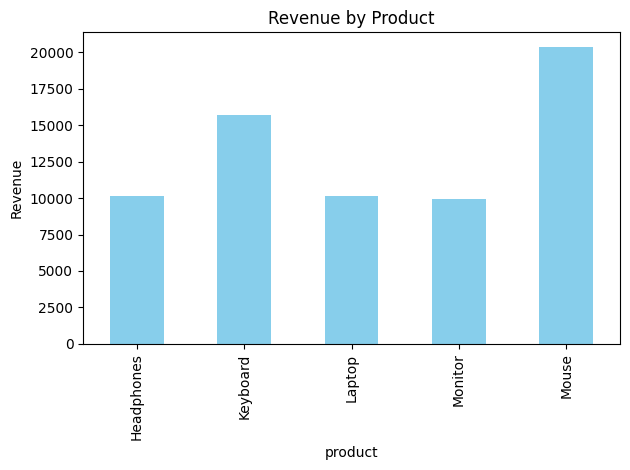

In [8]:
# Plot bar chart
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")